In [1]:
# TODO: adicionar um markdown para cada célula

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pytest
import math
from ucimlrepo import fetch_ucirepo 


# Classe RTrainer

A classe RTrainer possui 4 métodos: inicialização, separação dos dados de treinamento, treinamento e por fim a predição do modelo

## Inicialização

É o construtor do nosso modelo, possui como parâmetros:

- Taxa de aprendizado -> passos do modelo em direção a convergência
- Ephocs -> iterações do modelo para o treinamento
- Erro -> erro que podemos usar para dizer que o modelo convergiu o suficiente para parar o treinamento antes de todas as iterações
- Logger -> opcional, mas serve para termos informações ao longo do treinamento

Além disso, possui atributos como parâmetros, médias e desvios padrões para treinamento/retorno do modelo

## Separação dos dados de treinamento

É um modulo que separa dos dados de treinamento em 3 partes: treinamento, teste e validação. Possui como argumentos: um dataframe de entrada, um de saída opcional, a coluna de output opcional e argumentos opcionais de normalização da entrada/output

Para lidar com uma maior gama de entrada de tipos de entrada, adicionei mais parâmetros, caso o usuário só passe um dataframe de entrada, preciso saber qual é a coluna de saída, do contrário retorno um erro. No caso de passar um dataframe de saída, junto com o de entrada pelos índices, fazendo com que cada linha seja a entrada/saída esperada.

Após isso, uso de uma função nativa do numpy para realizar a randomização dos dados, por isso precisamos juntar os dataframes, para garantir que a entrada correspondente seja a mesma da saída.

No próximo passo, temos um corte nos dados, os primeiros 70% são do conjunto de teste, os próximos 20% são do de validação, e por fim, os últimos 10% do conjunto de teste

Por fim, temos a normalização dos dados, dado o argumento opcional, que por padrão é aplicado a normalização z-score

- Por que normalizar os dados de saída? 
    
    No meu caso, o custo do modelo estava muito alto, o que de certa forma era o esperado para uma saída no formato que estava, por isso, inclusive que eu mantenho como um atributo da classe as médias e os desvios, para realizar a "desnormalização" dos dados quando estou retornando para o usuário. Além disso, para ser uma coisa mais auditável, eu não normalizo as saídas esperadas do modelo.


## Treinamento

Esse módulo é autoexplicativo por nome, recebe como argumentos os dataframes que vem da separação dos dados de treinamento.

De forma a aproveitar a biblioteca numpy que já realiza operações em matrizes de forma muito mais rápida, a primeira coisa que faço é transformar os dataframes dos argumentos em um array do tipo numpy. 

Os dados de entrada, X, vão ficar no formato (N, M), sendo N o número de linhas de entrada que temos e M o número de features. Enquanto que, os dados de previsão ficarão no formato (N,), ou seja, uma matriz unidimensional de N entradas, para garantir que vamos ter uma matriz unidimensional eu aplico a função .raven(). Dessa forma, o que temos inicialmente é:

X = $\begin{bmatrix} x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M}$ e Y = $\begin{bmatrix} y_1 \\\ y_2 \\\ ... \\\ y_n \end{bmatrix}_{N,}$

Por conta do $\theta_0$, uma das formas que eu achei para lidar com ele foi adicionar um pequeno vetor de 1s para garantir que consigamos realizar a multiplicação entre a matriz de entrada e o vetor de parâmetros. Dessa forma, atualizamos a nossa matriz para:

X = $\begin{bmatrix} 1& x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ 1& x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ 1& x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M+1}$

Após isso, inicializo o vetor de parâmetros

$\theta $ = $\begin{bmatrix} \theta_0 \\\ \theta_1 \\\ ... \\\ \theta_{m} \end{bmatrix}_{M+1,1}$

Onde $\theta_0, \theta_1, ..., \theta_{m}$ são inicializados com o valor 1.


Após a inicialização dos parâmetros, nós finalmente começamos o treinamento, a cada iteração, realizamos as seguintes ações:

- Multiplicação da matriz entrada de treinamento pelo vetor de parâmetros

$\begin{bmatrix} 1& x_{1,1}& x_{1,2}& ...& x_{1,m} \\\ 1& x_{2,1}& x_{2,2}& ...& x_{2,m}  \\\ ... \\\ 1& x_{n,1}& x_{n,2}& ...& x_{n,m} \end{bmatrix}_{N,M+1}$ * $\begin{bmatrix} \theta_0& \theta_1& ...& \theta_{m} \end{bmatrix}^T_{M+1,1}$ = $\begin{bmatrix} y_1 \\\ y_2 \\\ ... \\\ y_n \end{bmatrix}_{N,1}$

- Mutiplicação da matriz de validação pelo vetor de parâmetros

$\begin{bmatrix} 1& x^´_{1,1}& x^´_{1,2}& ...& x^´_{1,m} \\\ 1& x^´_{2,1}& x^´_{2,2}& ...& x^´_{2,m}  \\\ ... \\\ 1& x^´_{n,1}& x^´_{n,2}& ...& x^´_{n,m} \end{bmatrix}_{N,M+1}$ * $\begin{bmatrix} \theta_0& \theta_1& ...& \theta_{m} \end{bmatrix}^T_{M+1,1}$ = $\begin{bmatrix} ý_1 \\\ ý_2 \\\ ... \\\ ý_n \end{bmatrix}_{N,1}$
- Cálculo do custo utilizando a função:

$ J(\theta) = 1/(2*m) * \sum_{i=0}^{m}(ý- y)^2$
    
Onde m = número de entradas do conjunto de validação, ý é a saída do modelo e y é a saída esperada

- Cálculo do gradiente

Aplicando a fórmula apresentada no slide, temos que:

gradientes = (1/m) * $\begin{bmatrix} 1& 1& ...& 1& \\\ x^´_{1,1}& x^´_{2,1}& ...& x^´_{n,1}& \\\ x^´_{1,2}& x^´_{2,2}&  ...& x^´_{n,2} \\\ ... \\\ x^´_{1,m}& x^´_{2,m}& ...& x^´_{n,m} \end{bmatrix}_{M+1, N}$ * $\begin{bmatrix} ý_1 - y_1 \\\ ý_2 - y_2 \\\ ... \\\ ý_n - y_n \end{bmatrix}_{N,1}$

Onde aplicamos a transposta da matriz da entrada, dessa forma vamos ter a matriz resultado com a quantidade de features esperada -> M+1

- Atualização dos parâmetros

$\theta = \theta - \alpha * gradiente$

Onde $\alpha$ é a taxa de aprendizado


E por fim, temos a construção de um gráfico que mostra a relação entre custo x taxa de aprendizado e o retorno do vetor de parâmetros do modelo naquela base de dados

## Predição

Antes do modelo realizar os cálculos, ele adiciona novamente o coeficiente constante do $\theta_0$ para podermos realizar a multiplicação de matrizes sem problema

Após isso, apenas retornamos o resultado

In [375]:
class RTrainer:
    # Etapa de treinamento, é a mais simples, implementação está no slide
    def __init__(self, a, ephocs, erro=0, logger=False):
        """Construtor da classe RTrainer"""
        self.a = a # Taxa de aprendizado
        self.ephocs = ephocs # Quantidade de iterações do modelo
        self.erro = erro # Erro mínimo, um parâmetro adicional na hora de iterar, opcional
        self.logger = logger # Um log para acompanharmos algumas coisas que possam ser interessantes de serem observadas
        self.parametros: np.ndarray
        self.media_entrada_treinamento = 0
        self.desvio_entrada_treinamento = 1
        self.media_previsao_treinamento = 0
        self.desvio_previsao_treinamento = 1

    def train_test_validation_split(self, entrada: pd.DataFrame, saida: pd.DataFrame | None = None, output: str | None = None, normalizar: bool | None = None, normalizar_output: bool | None = None):
        """ Função que vai fazer o embaralhamento dos dados, para garantir que não haja nenhum viés no treinamento. Além disso, separamos os dados em treinamento, validação e teste. Vamos passar um único Dataframe e vamos separar aqui dentro"""

        if saida is None and output is None:
            # Ver trowexception
            return("Erro: preciso de: ou um dataframe de saída ou de uma coluna referenciando o output no dataframe de entrada")

        coluna_Y = ''
        randomizando_dataframe = ''

        # Se não tiver sido passado uma string, e sim um dataframe, vamos pegar a coluna de saída e juntar no dataframe de entrada
        if output is None:
            coluna_Y = saida.columns[0]
            randomizando_dataframe = pd.concat([entrada, saida], axis=1)
        else:
            coluna_Y = output
            randomizando_dataframe = entrada.copy()

        # Processo de "bagunçar" o dataframe
        randomizando_dataframe = randomizando_dataframe.iloc[np.random.permutation(len(randomizando_dataframe))].reset_index(drop=True) # -> Usando o numpy para rearranjar os elementos, mantendo os índices normais

        corteTeste = int(len(randomizando_dataframe)*0.70)
        corteValidacao = int(len(randomizando_dataframe)*0.90)

        parteTreinamento = randomizando_dataframe[:corteTeste] # Primeiros 70% do dataframe
        parteValidacao = randomizando_dataframe[corteTeste:corteValidacao] # Próximos 20%
        parteTeste = randomizando_dataframe[corteValidacao:] # Últimos 10%

        # Separando os três dataframes:

        colunas_X = []

        for i in randomizando_dataframe.columns:
            if i != coluna_Y:
                colunas_X.append(i)

        X_train, y_train = parteTreinamento[colunas_X].copy(), parteTreinamento[coluna_Y].copy()
        X_val, y_val = parteValidacao[colunas_X].copy(), parteValidacao[coluna_Y].copy()
        X_test, y_test = parteTeste[colunas_X].copy(),  parteTeste[coluna_Y].copy()

        # Caso queiramos normalizar os dados
        if normalizar:
            self.media_entrada_treinamento = X_train[colunas_X].mean()
            self.desvio_entrada_treinamento = X_train[colunas_X].std().replace(0, 1) # entender esse replace

            X_train[colunas_X] = (X_train[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento
            X_val[colunas_X] = (X_val[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento 
            X_test[colunas_X] = (X_test[colunas_X] - self.media_entrada_treinamento) / self.desvio_entrada_treinamento

            if normalizar_output: 

                self.media_previsao_treinamento = y_train.mean()
                self.desvio_previsao_treinamento = y_train.std()

                y_train = (y_train - self.media_previsao_treinamento) / self.desvio_previsao_treinamento
                y_val = (y_val - self.media_previsao_treinamento) / self.desvio_previsao_treinamento
                # y_test = (y_test - self.media_previsao_treinamento) / self.desvio_previsao_treinamento

        return X_train, y_train, X_val, y_val, X_test, y_test

    def fit(self, dados_entrada_treinamento: pd.DataFrame, y_treinamento: pd.DataFrame, dados_entrada_val: pd.DataFrame, y_val: pd.DataFrame ) -> np.ndarray:
        """ Método que realiza o treinamento do modelo """

        if 'bias' not in dados_entrada_treinamento.columns:
            dados_entrada_treinamento.insert(0, column='bias', value=np.ones(dados_entrada_treinamento.shape[0]))
            dados_entrada_val.insert(0, column='bias', value=np.ones(dados_entrada_val.shape[0]))

        # Facilitando a vida do usuário e transformando aqui em um numpy array
        x_treinamento = dados_entrada_treinamento.to_numpy()
        y_treinamento = y_treinamento.to_numpy().ravel()
        x_val = dados_entrada_val.to_numpy()
        y_val = y_val.to_numpy().ravel()


        # TODO: Corrigir aqui para baixo -> acima eu já adiciono a entrada para o víes
        
        # Ok, temos a matriz dos dados de entrada, agora precisamos criar os parâmetros

        self.parametros = np.ones(x_treinamento.shape[1]) # TODO: adicionar um parâmetro opcional que possa definir o tipo de inicialização desse vetor de parâmetros, se é rand, 0 e 1, vai ser um if né simples
        historico_custo = []
        historico_lr = []

        # Agora podemos realizar as predições


        for i in range(self.ephocs):
            # Primeiro, precisamos calcular o vetor y_pred, que vai ser uma multiplicação de matrizes
            
            y_pred = x_treinamento @ self.parametros  # O "@" é o operador de multiplicação de matrizes do numpy
            y_pred_val = x_val @ self.parametros 

            custo = 1/(2*len(x_val[0])) * np.sum((y_pred_val - y_val)**2) 
            print(custo)

            historico_lr.append(self.a)
            historico_custo.append(custo)

            if custo < 0.001:
                break

            # Terceiro, aplicando o método do gradiente descendente para múltiplos atributos
            gradientes = (1 / x_treinamento[0]) * (x_treinamento.T @ (y_pred - y_treinamento))
            self.parametros = self.parametros - self.a * gradientes


        #print("ultimo custo: ", historico_custo[-1])
        plt.figure(figsize=(8, 5))
        plt.scatter(historico_lr, historico_custo, c=range(len(historico_lr)), cmap='viridis')
        plt.xlabel('Taxa de Aprendizado (LR)')
        plt.ylabel('Custo')
        plt.title('Custo vs. Taxa de Aprendizado')
        plt.show()
        
        return self.parametros


    #  TODO: fazendo retornar um valor só, rever isso aqui
    def predict(self, dados_predicao: np.ndarray) -> float:
        """Método que realiza previsão do modelo, vai retornar -> um vetor de parâmetros OU um objeto MODEL contendo ao menos uma propriedade que indique o número de parâmetros"""

        dados_normalizados = pd.concat([pd.Series(1), dados_predicao]) # Dessa forma resolvermos a questão do theta0

        return  (self.parametros @ np.transpose(dados_normalizados) * self.desvio_previsao_treinamento) + self.media_previsao_treinamento


In [369]:
df_sintetico = pd.DataFrame({
                'x': range(10),
                'y': [i*2 for i in range(10)]
})

print(df_sintetico.to_markdown(index=False))

|   x |   y |
|----:|----:|
|   0 |   0 |
|   1 |   2 |
|   2 |   4 |
|   3 |   6 |
|   4 |   8 |
|   5 |  10 |
|   6 |  12 |
|   7 |  14 |
|   8 |  16 |
|   9 |  18 |


In [370]:
class EvaluativeMetrics:
    # Instânciando a classe
    def __init__(self, y_pred: np.ndarray, y: np.ndarray):
        self.y_pred = y_pred
        self.y = y

    # Métrica MAE
    def MAE(self) -> float:
        """"""
        return 1/len(self.y_pred) * np.sum(abs(self.y_pred - self.y))

    # Métrica MAPE
    def MAPE(self) -> float:
        """"""
        return 100/len(self.y_pred) * np.sum(abs(self.y_pred - self.y)/self.y)

    # Métrica MSE:
    def MSE(self) -> float:
            """"""
            return 1/len(self.y_pred) * np.sum((self.y_pred - self.y)**2)



In [371]:
# TODO: Célula de testes


def testando_fit_modelo(modelo: RTrainer, dados_entrada: np.ndarray, y: np.ndarray):
    
    try:
        pesos = modelo.fit(dados_entrada, dados_entrada)
    except Exception as e:
        pytest.fail(f"O fit do modelo falhou por: {e}")

    # Verificação se os pesos que estão saindo do modelo estão tipados como se espera
    assert isinstance(pesos, np.ndarray)

    # Verificação da quantidade de pesos é n+1 da quantidade de colunas de entrada. Onde a quantidade de dimensões corresponde a quantidade de colunas e o shape corresponde a quatidade de parâmetros
    assert (dados_entrada.ndim + 1) == pesos.shape[0]

# TODO: Construir outras validações aqui

In [372]:
trainer = RTrainer(
    a = 0.001,
    ephocs=10000,
    logger=True
)

In [373]:
X_train_teste, y_train_teste, X_val_teste, y_val_teste, X_test_teste, y_test_teste = trainer.train_test_validation_split(df_sintetico, output="y", normalizar=False)

21.25
20.343766728395067
19.478477861338277
18.65223048763201
17.863211553747934
17.109693582629948
16.390030597477427
15.702654240667894
15.04607007845164
14.418854082501127
13.819649279826615
13.247162562977545
12.70016165283765
12.177472206691572
11.677975064592552
11.200603627395935
10.744341360142116
10.308219414775923
9.891314366478749
9.492746058164412
9.111675547951844
8.747303154676775
8.398866596741948
8.065639219831018
7.746928309226611
7.442073482677261
7.150445159953005
6.8714431054147465
6.604495040098992
6.349055319987567
6.104603677291937
5.870644021733941
5.646703298949628
5.432330403280927
5.227095142351239
5.0305872509458585
4.842415451837359
4.662206561309213
4.489604637238818
4.324270167703645
4.165879298172139
4.0141230954337885
3.868706846511523
3.729349390883706
3.5957824844234505
3.467750193539131
3.345008318072879
3.227323841582904
3.1144744077015485
3.0062478213235164
2.9024415734386206
2.802862388480058
2.7073257931135286
2.615655705443786
2.527684043664543


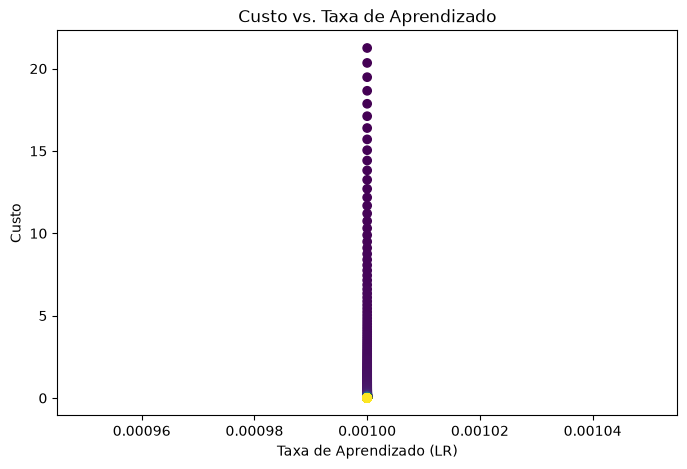

In [374]:
vetores_peso = trainer.fit(X_train_teste, y_train_teste, X_val_teste, y_val_teste)

In [31]:
print(X_test_teste)

   x
3  3


In [32]:

print(trainer.predict(X_test_teste.iloc[0]))
print(y_test_teste.iloc[0])

0    1
x    3
dtype: int64
[0.10715121 1.82662697]
5.587032122704914
6


In [73]:
df = pd.read_csv("data/insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [74]:
# Tratando alguns dados

def one_hot_sex(sex: str):
    if sex == "female":
        return 1
    else:
        return 0
    

In [75]:
df['sex'] = df['sex'].apply(one_hot_sex)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
5,31,1,25.740,0,no,southeast,3756.62160
6,46,1,33.440,1,no,southeast,8240.58960
7,37,1,27.740,3,no,northwest,7281.50560
8,37,0,29.830,2,no,northeast,6406.41070
9,60,1,25.840,0,no,northwest,28923.13692


In [76]:
def one_hot_region(region: str):
    if region == 'southwest':
        return 1
    else:
        return 0

In [77]:
df['region'] = df['region'].apply(one_hot_region)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,1,16884.92400
1,18,0,33.770,1,no,0,1725.55230
2,28,0,33.000,3,no,0,4449.46200
3,33,0,22.705,0,no,0,21984.47061
4,32,0,28.880,0,no,0,3866.85520
5,31,1,25.740,0,no,0,3756.62160
6,46,1,33.440,1,no,0,8240.58960
7,37,1,27.740,3,no,0,7281.50560
8,37,0,29.830,2,no,0,6406.41070
9,60,1,25.840,0,no,0,28923.13692


In [78]:
def one_hot_smoke(smoker: str):
    if smoker == 'yes':
        return 1
    else:
        return 0

In [79]:
df['smoker'] = df['smoker'].apply(one_hot_smoke)
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,1,16884.92400
1,18,0,33.770,1,0,0,1725.55230
2,28,0,33.000,3,0,0,4449.46200
3,33,0,22.705,0,0,0,21984.47061
4,32,0,28.880,0,0,0,3866.85520
5,31,1,25.740,0,0,0,3756.62160
6,46,1,33.440,1,0,0,8240.58960
7,37,1,27.740,3,0,0,7281.50560
8,37,0,29.830,2,0,0,6406.41070
9,60,1,25.840,0,0,0,28923.13692


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


In [88]:
series = df['charges']

In [91]:
series.mean()

np.float64(13270.422265141257)

In [145]:
X_train, y_train, X_val, y_val, X_test, y_test = trainer.train_test_validation_split(df, output="charges", normalizar=True, normalizar_output=True)

In [144]:
trainer = RTrainer(
    a = 0.001,
    ephocs=100000,
    logger=True
)

dados_entrada_treinamento ->  (936, 6)
y_treinamento ->  (936,)
dados_entrada_val ->  (268, 6)
y_val ->  (268,)
x_treinamento ->  2
x_val ->  2
2.4223939700517647
2.417708131326966
2.4130320173558233
2.4083656077010778
2.403708881968859
2.3990618198085936
2.3944244009129187
2.3897966050175796
2.3851784119013457
2.380569801385913
2.3759707533358156
2.3713812476583307
2.366801264303391
2.3622307832634903
2.357669784573592
2.3531182483110418
2.348576154595473
2.344043483588717
2.3395202154947157
2.3350063305594264
2.3305018090707352
2.326006631358368
2.3215207777937983
2.317044228790157
2.312576964802149
2.3081189663259565
2.3036702138991556
2.299230688100627
2.294800369550464
2.290379238909889
2.2859672768811627
2.281564464207496
2.2771707816729636
2.2727862101024168
2.268410730361394
2.264044323356035
2.259686970032996
2.2553386513793585
2.250999348422548
2.2466690422302413
2.242347713910287
2.2380353446106134
2.2337319155191495
2.2294374078637316
2.2251518029120247
2.2208750819714327
2

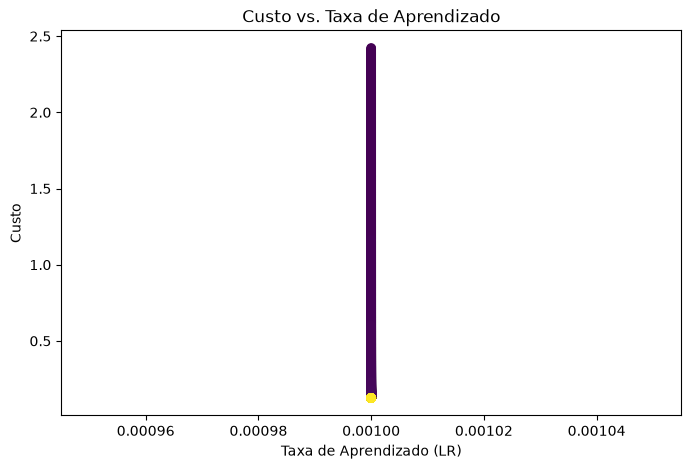

In [146]:
vetores_peso = trainer.fit(X_train, y_train, X_val, y_val)

In [148]:
print(trainer.predict(X_test.iloc[0]))
print(y_test.iloc[0])

15997.515465014661
12950.0712
